# Complex industrial problem

**Autor:** Gil Brandon Garcia Contreras
**Matricula:** A01254164
**Fecha:** 3 de marzo de 2026

Para esta parte de la tarea me decidí por encontrar un dataset de un tema de mi interés particular: el teatro. Para esto localicé una base de datos de producciones de Broadway donde mi intención es categorizar el tipo con las variables presentes de la producción. El propósito detrás de esto es poder determinar el tipo de producción únicamente con la información colindante y tener la habilidad de categorizarlas con esta información. El dataset cuenta con 31,296 registros desde 1990 hasta 2015 con 11 features diferentes para predecir el tipo. Sin embargo, tras aplicar un proceso de limpieza de datos, únicamente 26,926 registros con 7 feutures quedaron disponibles. Este dataset está proporcionado por Broadway League (the national trade association for the Broadway industry) y los datos están disponibles en http://www.broadwayleague.com/, pero fueron extraídos mediante el siguiente enlace https://corgis-edu.github.io/corgis/csv/broadway/. 


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Decission Tree
from sklearn import tree
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.tree import plot_tree, DecisionTreeClassifier
from imblearn.over_sampling import RandomOverSampler

# Random Forest
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize

# KNN
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# SVM
from sklearn.svm import SVC

In [3]:
from sklearn.model_selection import RandomizedSearchCV


## Importar Dataset

In [4]:
col_names = ['day', 'date', 'month', 'year', 'name', 'theatre', 'type', 'attendance', 'capacity', 'gross', 'gross_potential', 'performance'] 

df = pd.read_csv('../../broadway.csv', names=col_names, header=None, skiprows=1)

display(df.head(10))

display(df.describe())

display(df.info())

,day,date,month,year,name,theatre,type,attendance,capacity,gross,gross_potential,performance
0,26,8/26/1990,8,1990,Tru,Booth,Play,5500,88,134456,0,8
1,24,3/24/1991,3,1991,Miss Saigon,Broadway,Musical,1737,100,100647,0,0
2,31,3/31/1991,3,1991,Miss Saigon,Broadway,Musical,12160,100,634424,0,0
3,7,4/7/1991,4,1991,Miss Saigon,Broadway,Musical,13921,100,713353,0,0
4,14,4/14/1991,4,1991,Miss Saigon,Broadway,Musical,10973,90,573981,0,4
5,21,4/21/1991,4,1991,Miss Saigon,Broadway,Musical,14076,101,706793,0,8
6,28,4/28/1991,4,1991,Miss Saigon,Broadway,Musical,14065,101,714968,0,8
7,5,5/5/1991,5,1991,Miss Saigon,Broadway,Musical,14064,101,730765,0,8
8,12,5/12/1991,5,1991,Miss Saigon,Broadway,Musical,13896,100,766713,0,8
9,19,5/19/1991,5,1991,Miss Saigon,Broadway,Musical,13738,99,763332,0,8


,day,month,year,attendance,capacity,gross,gross_potential,performance
count,31296.000000,31296.000000,31296.000000,31296.000000,31296.000000,3.129600e+04,31296.000000,31296.000000
mean,15.720859,6.509043,2005.875128,8010.523006,80.738912,5.960688e+05,62.404045,7.224821
std,8.817000,3.430321,6.100118,3189.873933,18.842815,3.809796e+05,28.714589,2.235376
min,1.000000,1.000000,1990.000000,24.000000,10.000000,1.037000e+03,0.000000,0.000000
25%,8.000000,4.000000,2001.000000,5508.000000,70.000000,3.201085e+05,45.000000,8.000000
50%,16.000000,6.000000,2006.000000,7801.500000,83.000000,5.145200e+05,63.000000,8.000000
75%,23.000000,10.000000,2011.000000,10348.000000,95.000000,7.852690e+05,82.000000,8.000000
max,31.000000,12.000000,2016.000000,21631.000000,892.000000,3.201333e+06,226.000000,16.000000


<class 'pandas.DataFrame'>
RangeIndex: 31296 entries, 0 to 31295
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   day              31296 non-null  int64
 1   date             31296 non-null  str  
 2   month            31296 non-null  int64
 3   year             31296 non-null  int64
 4   name             31296 non-null  str  
 5   theatre          31296 non-null  str  
 6   type             31296 non-null  str  
 7   attendance       31296 non-null  int64
 8   capacity         31296 non-null  int64
 9   gross            31296 non-null  int64
 10  gross_potential  31296 non-null  int64
 11  performance      31296 non-null  int64
dtypes: int64(8), str(4)
memory usage: 2.9 MB


None

## Limpieza

In [5]:
df = df.drop('date', axis=1)
df = df.drop('name', axis=1)
df = df.drop('theatre', axis=1)
df = df.drop('year', axis=1)

df = df[df['gross_potential'] != 0]
df = df[df['performance'] != 0]

display(df.describe())

,day,month,attendance,capacity,gross,gross_potential,performance
count,26926.000000,26926.000000,26926.000000,26926.00000,2.692600e+04,26926.000000,26926.000000
mean,15.743111,6.522432,8110.865929,80.57944,6.261639e+05,68.044307,7.824890
std,8.812606,3.412446,3090.474404,17.46907,3.875792e+05,23.801318,0.870978
min,1.000000,1.000000,49.000000,10.00000,1.648000e+03,4.000000,1.000000
25%,8.000000,4.000000,5687.000000,70.00000,3.451535e+05,50.000000,8.000000
50%,16.000000,6.000000,7897.000000,83.00000,5.386790e+05,66.000000,8.000000
75%,23.000000,10.000000,10358.750000,95.00000,8.244110e+05,85.000000,8.000000
max,31.000000,12.000000,21144.000000,747.00000,3.201333e+06,226.000000,15.000000


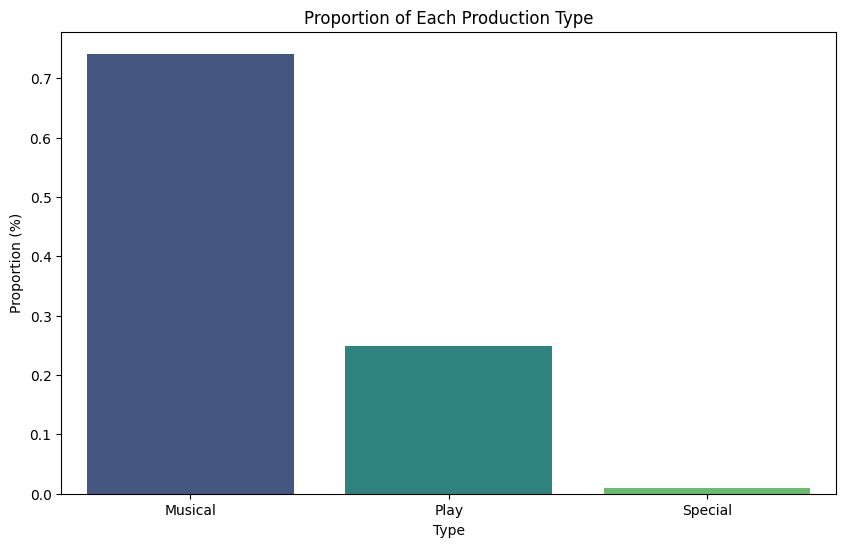

Counter({'Musical': 19960, 'Play': 6693, 'Special': 273})


In [6]:
X = df.drop('type', axis=1)
y = df['type']

porcentajes = y.value_counts(normalize=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=porcentajes.index, y=porcentajes.values, hue=porcentajes.index, palette='viridis')
plt.title('Proportion of Each Production Type')
plt.xlabel('Type')
plt.ylabel('Proportion (%)')
plt.show()
print(Counter(y))

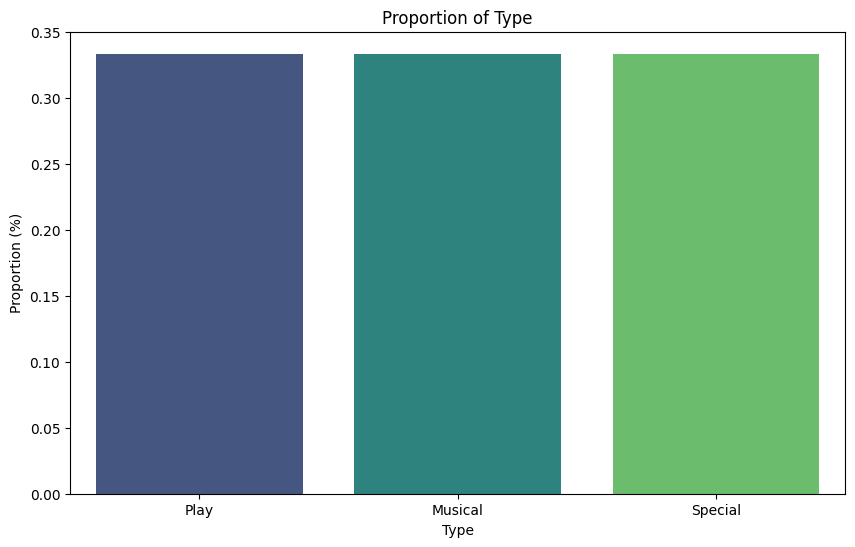

Counter({'Play': 13962, 'Musical': 13962, 'Special': 13962})


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

porcentajes_balanced = y_train_balanced.value_counts(normalize=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=porcentajes_balanced.index, y=porcentajes_balanced.values, hue=porcentajes_balanced.index, palette='viridis')
plt.title('Proportion of Type')
plt.xlabel('Type')
plt.ylabel('Proportion (%)')
plt.show()
print(Counter(y_train_balanced))

# Deccision Tree

## Hiperparametros para Deccision Tree

In [16]:
clf = DecisionTreeClassifier()

param_grid = {
    'max_depth' : [2, 3, 4, 5, None],
    'min_samples_split' : [2, 4, 6, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [None, 5, 10, 20]
}

grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1, verbose=1)
grid_search.fit(X_train_balanced, y_train_balanced)

best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Best Hyperparameters: {'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


## Modelo Deccision Tree

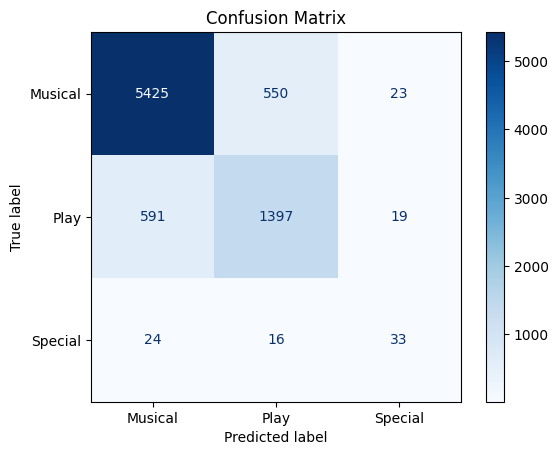

Classification Report:
                precision    recall  f1-score   support

     Musical       0.90      0.90      0.90      5998
        Play       0.71      0.70      0.70      2007
     Special       0.44      0.45      0.45        73

    accuracy                           0.85      8078
   macro avg       0.68      0.68      0.68      8078
weighted avg       0.85      0.85      0.85      8078



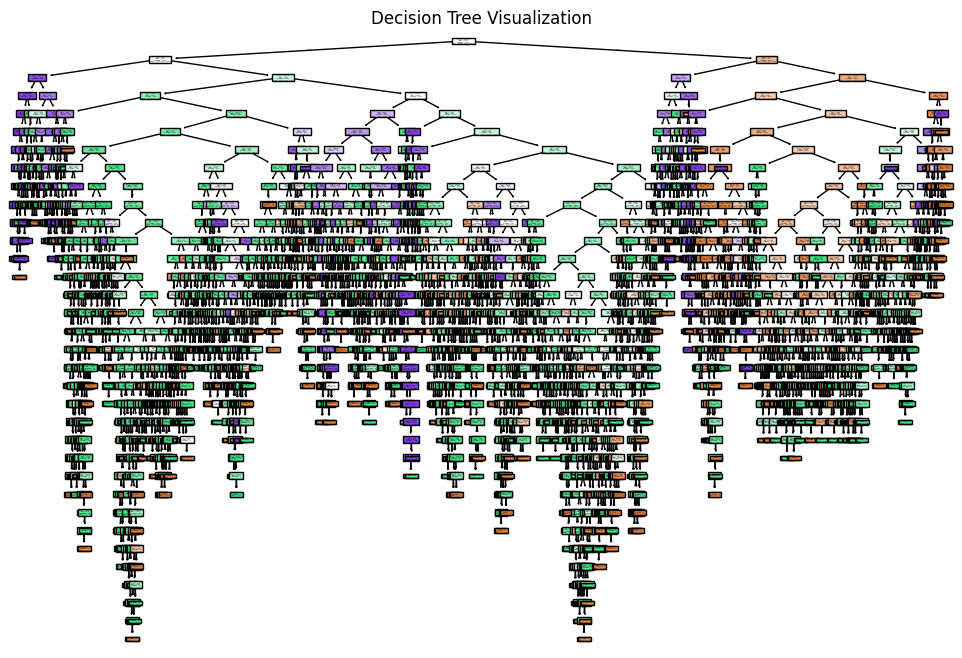

In [17]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

report = classification_report(y_test, y_pred, labels=best_model.classes_)
print('Classification Report:\n ', report)

plt.figure(figsize=(12, 8))
plot_tree(best_model, filled=True)
plt.title('Decision Tree Visualization')
plt.show()

# Random Forest

## Acurracy for number of trees

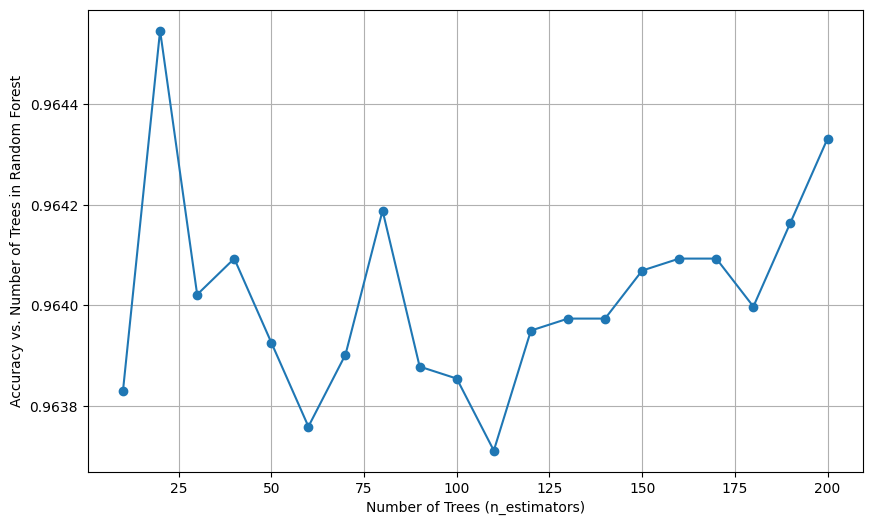

In [18]:
n_estimators_range = range(10, 201, 10)
cv_scores = []
for n in n_estimators_range:
    rf_temp = RandomForestClassifier(n_estimators = n, random_state = 42, n_jobs = -1)
    scores = cross_val_score(rf_temp, X_train_balanced, y_train_balanced, cv = 5, scoring = 'accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, cv_scores, marker = 'o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy vs. Number of Trees in Random Forest")
plt.grid(True)
plt.show()

## Hiperparametros para RandomForest

In [19]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, None],
    'min_samples_split' : [2, 4, 6], 
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

rf = RandomForestClassifier(random_state = 42)
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1, verbose = 1)
grid_search.fit(X_train_balanced, y_train_balanced)
best_model = grid_search.best_estimator_
print("Best Hyperparameters: ", grid_search.best_params_) 

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Hyperparameters:  {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


## Modelo para RandomForest

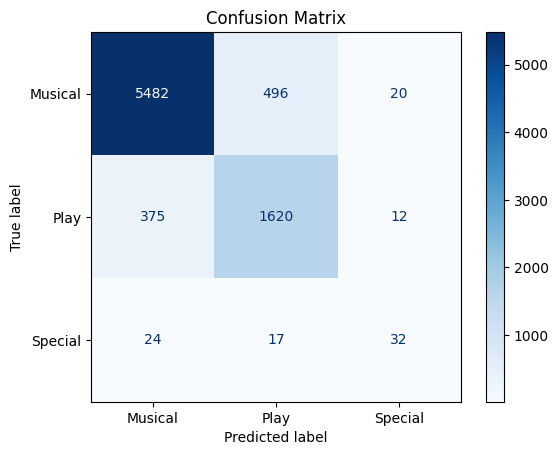

Classification Report: 
              precision    recall  f1-score   support

     Musical       0.93      0.91      0.92      5998
        Play       0.76      0.81      0.78      2007
     Special       0.50      0.44      0.47        73

    accuracy                           0.88      8078
   macro avg       0.73      0.72      0.72      8078
weighted avg       0.89      0.88      0.88      8078



<function matplotlib.pyplot.grid(visible: 'bool | None' = None, which: "Literal['major', 'minor', 'both']" = 'major', axis: "Literal['both', 'x', 'y']" = 'both', **kwargs) -> 'None'>

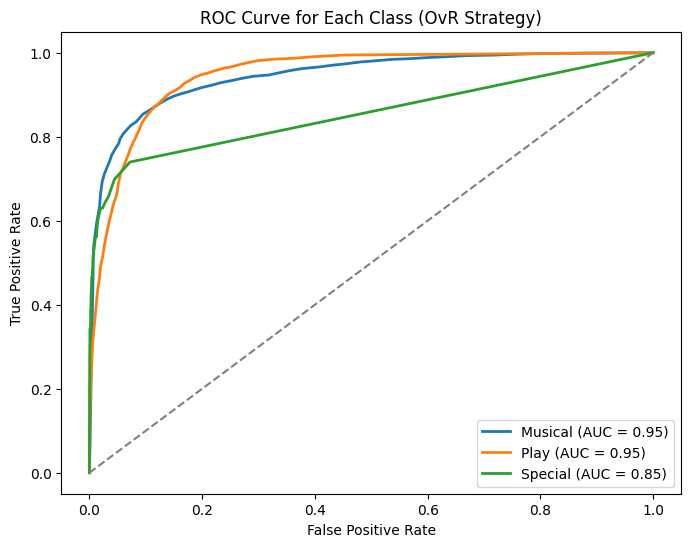

In [20]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels = best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = best_model.classes_)
disp.plot(cmap = plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

report = classification_report(y_test, y_pred, labels = best_model.classes_)
print("Classification Report: ")
print(report)

y_test_binarized = label_binarize(y_test, classes = best_model.classes_)
y_score = best_model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_label in enumerate(best_model.classes_):
    fpr[class_label], tpr[class_label], _ = roc_curve(y_test_binarized[:,i], y_score[:, i])
    roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])

plt.figure(figsize=(8, 6))
for class_label in best_model.classes_:
    plt.plot(fpr[class_label],tpr[class_label], lw =2, 
             label = f'{class_label} (AUC = {roc_auc[class_label]:.2f})')

plt.plot([0,1], vm = SVC(probability=True, random_state=42)
[0,1], color='gray', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class (OvR Strategy)')
plt.legend(loc = "lower right")
plt.grid

# SVM

## Hiperparametros para SVM

In [ ]:
param_grid = {
    'C' : [0.1, 1, 10, 100],
    'kernel' : ['linear', 'rbf', 'poly'],
    'gamma' : ['scale', 'auto']
}

svm = SVC(probability=True, random_state=42)

grid_search = RandomizedSearchCV(estimator=svm, param_distributions=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print('Best Hyperparamter:', grid_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


## Modelo para SVM

In [ ]:
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confussion Matrix')
plt.show
report = classification_report(y_test, y_pred, labels=best_model.classes_)
print(report)

y_test_binarized = label_binarize(y_test, classes = best_model.classes_)
y_score = best_model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_label in enumerate(best_model.classes_):
    fpr[class_label], tpr[class_label], _ = roc_curve(y_test_binarized[:,i], y_score[:, i])
    roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])

plt.figure(figsize=(8, 6))
for class_label in best_model.classes_:
    plt.plot(fpr[class_label],tpr[class_label], lw =2, 
             label = f'{class_label} (AUC = {roc_auc[class_label]:.2f})')

plt.plot([0,1], vm = SVC(probability=True, random_state=42)
[0,1], color='gray', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class (OvR Strategy)')
plt.legend(loc = "lower right")
plt.grid

# Conclusiones Finales

Con la intención de abarcar una mayor cantidad de modelos y ver el contraste entre ellos decidí analizar el problema mediante los siguientes modelos: DecissionTree, RandomForest y SVM (Support Vector Machine). Inicie el proceso con la limpieza del DataFrame eliminando todos los datos a los cuales no le podía ver sentido lógico como lo son "0 funciones". También, elimine todas las columnas de información no numéricas: fecha, nombre de la pieza y nombre del teatro. Posterior a esto, se optó por eliminar el año para no caer en el problema de series de tiempo. Una vez terminada la limpieza de datos analice los porcentajes de la variable a predecir y note una gran desproporción dentro de los datos. Por esto opté por hacer oversampling a la variable type para mitigar los efectos de la distribución y tener modelos más justos. 

Una vez hecha todo esto, me di a la tarea de crear diferentes modelos vistos en clase. Trata de poner en marcha con el más simple de todos DecisionTree, el cual demostró no ser tan malo a la hora de predecir las producciones, con valores considerablemente entonces en su report note que uno de los tipos iba a ser especialmente difícil de predecir: la categoría especial. Esta categoría es particular porque existen muy pocos registros hechos dentro de ella por lo que identificar patrones sería difícil para cualquier modelo que se implemente. Note que, aun con los hiperparámetros, el árbol de decisión quedan sumamente amplio lo cual me hace pensar en lo complejo que puedo ser encontrar patrones dentro de este dataset específico. En general quedo satisfecho con el rendimiento del modelo par ser de los menos complejos de todos. 

Siguiendo esta misma línea opté por hacer el modelo RandomForest para poder hacer una comparación directo con DecissionTree. El modelo tardo más en encontrar los hiperparámetros correctos, pero la recompensa fue un nivel de accuracy considerablemente mayor a DecissionTree con mejor precission y recall en musical y play. La categoría especial sigue sin poder ser predecible por RandomForest lo cual refuerza la idea de que existen pocos registros para hacer la comparación. Sin embargo, la curva roc mostró que las categorías presentan un comportamiento esperado lo cual indica un modelo confiable. 

Finalmente, decidí tratar el modelo SVM, ya que se percibe como el mejor de los cuatro vistos en clase y me parecía interesante como se compararía con el modelo de RandomForest. No obstante, deje corriendo el modelo por 3 horas y fue incapaz de dar una solución, debido a falta de tiempo no pude hacer la comparación apropiada para este último modelo. Esto me hace sentir apenado y seguiré viendo formas de optimizar el modelo para que no sea tan computacionalmente demandante. 

En conclusión, el hacer esta actividad me ayudo a tener un mejor entendimiento de los diferentes modelos y los métodos para poder optimizarlos. También, me enseño estrategias para enfrentar problemas comunes en los DataFrames como lo son la diferencia de clases o los valores nulos. En general me voy de esta práctica con sentimientos mixtos, ya que aunque aprendí mucho, el hecho de no poder haberlo completado de manera oportuna me pesa personalmente. 